# Supplementary Figure 5

Computational panels A–E.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


In [2]:
import importlib.util
import json
from pathlib import Path

import matplotlib as mpl

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

In [3]:
_HERE = ROOT
_ROOT = next((candidate for candidate in (_HERE, *_HERE.parents) if (candidate / 'environment.yml').is_file()))
_DATA_DIR = _ROOT / 'src' / 'manuscript_figures' / 'fig2'
_OUTPUT_DIR = _DATA_DIR / 'generated'
_STYLE = _ROOT / 'src' / 'manuscript_figures' / 'style.mplstyle'
if _STYLE.is_file():
    plt.style.use(_STYLE)
mpl.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 150, 'savefig.dpi': 300, 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'text.parse_math': False})
_flag_style_path = _ROOT / 'src' / 'manuscript_figures' / 'flag_style.py'
_flag_spec = importlib.util.spec_from_file_location('fig2_notebook_flag_style', _flag_style_path)
if _flag_spec is None or _flag_spec.loader is None:
    raise RuntimeError(f'Could not load flag palette from {_flag_style_path}')
_flag_style = importlib.util.module_from_spec(_flag_spec)
_flag_spec.loader.exec_module(_flag_style)
FLAG_ORDER = tuple(_flag_style.FLAG_ORDER)
FLAG_LABELS = dict(_flag_style.FLAG_LABELS)
FLAG_COLORS = dict(_flag_style.flag_colors(cvd_safe=False))
UNFLAGGED_KEY = _flag_style.UNFLAGGED_KEY
UNFLAGGED_COLOR = _flag_style.UNFLAGGED_COLOR
_expected_flag_colors = {'agree': '#6fc46f', 'disagree': '#ec835a', 'inferred': '#c7e1a3', 'no_literature': '#c3c2b7'}
if FLAG_COLORS != _expected_flag_colors:
    raise RuntimeError(f'The shared flag palette drifted from the canonical panel-G colors: {FLAG_COLORS}')
_ARCH_COLORS = {'single': _flag_style.DERIVED_SECONDARY, 'multi': _flag_style.DERIVED_PRIMARY}
_SCOPE_ORDER = ('program_response', 'comparator_relationship', 'expected_program_test', 'cell_group_relationship', 'mixed')
_SCOPE_LABELS = {'program_response': 'Pathway or state change', 'comparator_relationship': 'Perturbation convergence/divergence', 'expected_program_test': 'Prior-prediction outcome', 'cell_group_relationship': 'Cell-group-dependent response', 'mixed': 'Other'}
_SCOPE_COLORS = {'program_response': '#0072B2', 'comparator_relationship': '#56B4E9', 'expected_program_test': '#CC79A7', 'cell_group_relationship': '#F0E442', 'mixed': '#332288'}
_CHROME = {'ink': '#111111', 'muted': '#66645f', 'axis': '#b9b8ae', 'grid': '#e6e5de', 'surface': '#ffffff', 'accessed': '#256abf', 'cited': '#b5407f', 'human': '#eb6834', 'deg': '#6B7075', 'high': '#4C78A8', 'moderate': '#8F6AAE', 'uncovered': _flag_style.NEUTRAL_ABSENT}
_s5a = pd.read_csv(_DATA_DIR / 'S5' / 'a' / 'replot_run_consumption.csv')
_s5b_rows = pd.read_csv(_DATA_DIR / 'S5' / 'b' / 'current_flag_deg_footprints.csv')
_s5b_bins = pd.read_csv(_DATA_DIR / 'S5' / 'b' / 'current_flag_composition_by_deg_bin.csv')
_s5c = pd.read_csv(_DATA_DIR / 'S5' / 'c' / 'current_flag_composition_by_pathway.csv')
_s5d_cells = pd.read_csv(_DATA_DIR / 'S5' / 'd' / 'deg_universe_cells.csv')
_s5d_findings = pd.read_csv(_DATA_DIR / 'S5' / 'd' / 'phenotype_findings_by_perturbation_deg_ordered.csv')
_s5e = pd.read_csv(_DATA_DIR / 'S5' / 'e' / 'final_local_signal_distribution.csv')

def _normalize_flag(value):
    if pd.isna(value):
        return ''
    return str(value).strip().casefold().replace(' ', '_')

def _heading(container, letter, title):
    container.suptitle(f'{letter}   {title}', x=0.02, y=0.995, ha='left', va='top', fontsize=10.5, fontweight='bold', color=_CHROME['ink'])

def _clean_axis(ax, grid_axis=None):
    ax.spines[['top', 'right']].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(_CHROME['axis'])
        ax.spines[side].set_linewidth(0.55)
    ax.tick_params(length=2.5, width=0.5, colors=_CHROME['muted'])
    if grid_axis:
        ax.grid(axis=grid_axis, color=_CHROME['grid'], linewidth=0.55)
        ax.set_axisbelow(True)

def _flag_handles():
    return [Patch(facecolor=FLAG_COLORS[key], edgecolor='none', label=FLAG_LABELS[key]) for key in FLAG_ORDER]

NOTEBOOK_SIZE_SCALE = 1.45
NOTEBOOK_FONT_SCALE = 1.15

def save_s5_panel(letter, drawer, size):
    # Expand paper-sized panels for legible inline inspection.
    notebook_size = tuple(value * NOTEBOOK_SIZE_SCALE for value in size)
    figure = plt.figure(figsize=notebook_size)
    drawer(figure)
    for text in figure.findobj(match=mpl.text.Text):
        text.set_fontsize(text.get_fontsize() * NOTEBOOK_FONT_SCALE)
    return (figure, [])
ARCH_COLORS = _ARCH_COLORS
CHROME = _CHROME
S5A_DATA = _s5a
S5B_BINS = _s5b_bins
S5B_ROWS = _s5b_rows
S5C_DATA = _s5c
S5D_CELLS = _s5d_cells
S5D_FINDINGS = _s5d_findings
S5E_DATA = _s5e
SCOPE_COLORS = _SCOPE_COLORS
SCOPE_LABELS = _SCOPE_LABELS
SCOPE_ORDER = _SCOPE_ORDER
clean_axis = _clean_axis
flag_handles = _flag_handles
heading = _heading
normalize_flag = _normalize_flag
output_dir = _OUTPUT_DIR
repo_root = _ROOT

## Supplementary Figure 5A

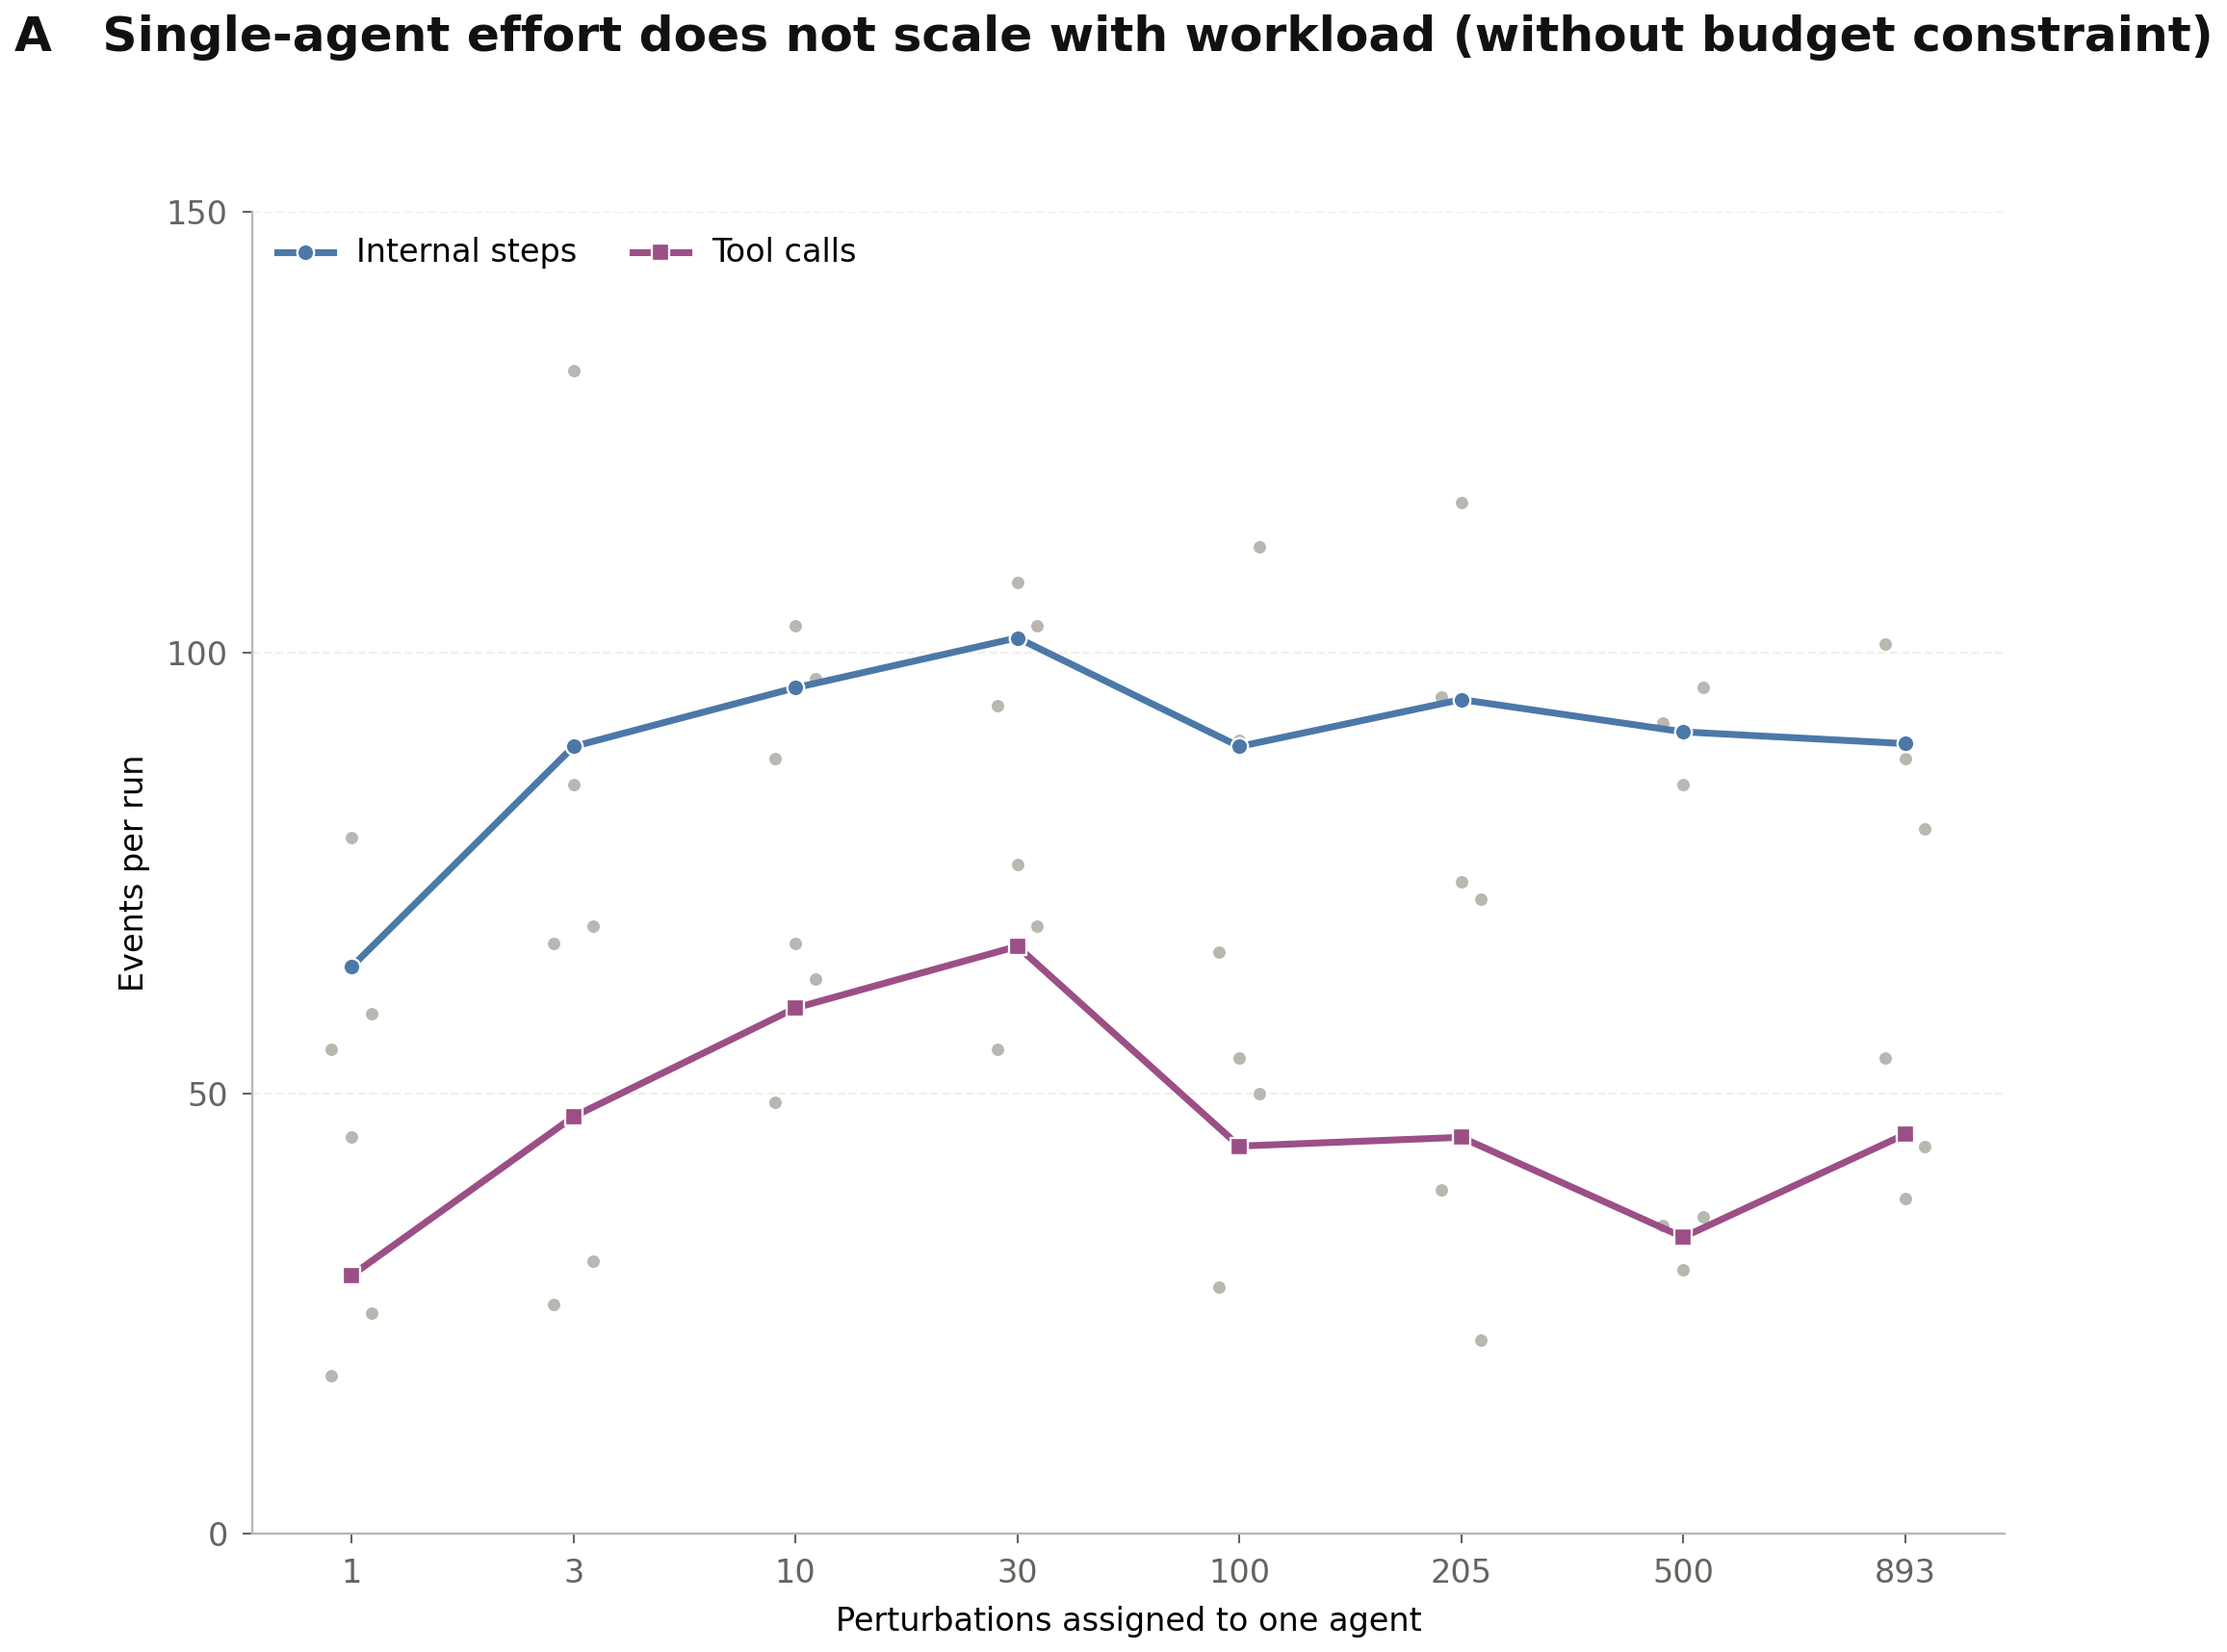

In [4]:
_CHROME = CHROME
_data = S5A_DATA
_clean_axis = clean_axis
_heading = heading

# ---------------------------------------------------------------- S5A
def draw_s5a(container):
    _heading(
        container,
        "A",
        "Single-agent effort does not scale with workload (without budget constraint)",
    )
    ax = container.subplots()
    scales = list(dict.fromkeys(_data["scale"].astype(int)))
    positions = np.arange(len(scales), dtype=float)
    seed_offsets = {
        seed: offset
        for seed, offset in zip(sorted(_data["seed"].unique()), (-0.09, 0.0, 0.09))
    }
    series = (
        ("steps", "Internal steps", _CHROME["high"], "o"),
        ("tool_calls", "Tool calls", "#9b4f86", "s"),
    )
    for metric, label, color, marker in series:
        for row in _data.itertuples():
            xpos = positions[scales.index(int(row.scale))] + seed_offsets[row.seed]
            ax.scatter(
                xpos,
                float(getattr(row, metric)),
                s=12,
                color="#b8b7b0",
                edgecolor="white",
                linewidth=0.35,
                zorder=2,
            )
        mean = _data.groupby("scale", sort=False)[metric].mean().reindex(scales)
        ax.plot(
            positions,
            mean.to_numpy(),
            color=color,
            marker=marker,
            markersize=4.2,
            markeredgecolor="white",
            markeredgewidth=0.55,
            linewidth=1.7,
            label=label,
            zorder=3,
        )
    ax.set_xticks(positions, [str(value) for value in scales])
    ax.set_xlabel("Perturbations assigned to one agent")
    ax.set_ylabel("Events per run")
    ax.set_ylim(0, 150)
    ax.set_yticks([0, 50, 100, 150])
    ax.legend(frameon=False, loc="upper left", ncol=2, fontsize=7.0)
    _clean_axis(ax, "y")

fig_s5a, outputs_s5a = save_s5_panel("A", draw_s5a, (5.4, 4.1))
fig_s5a;

## Supplementary Figure 5B

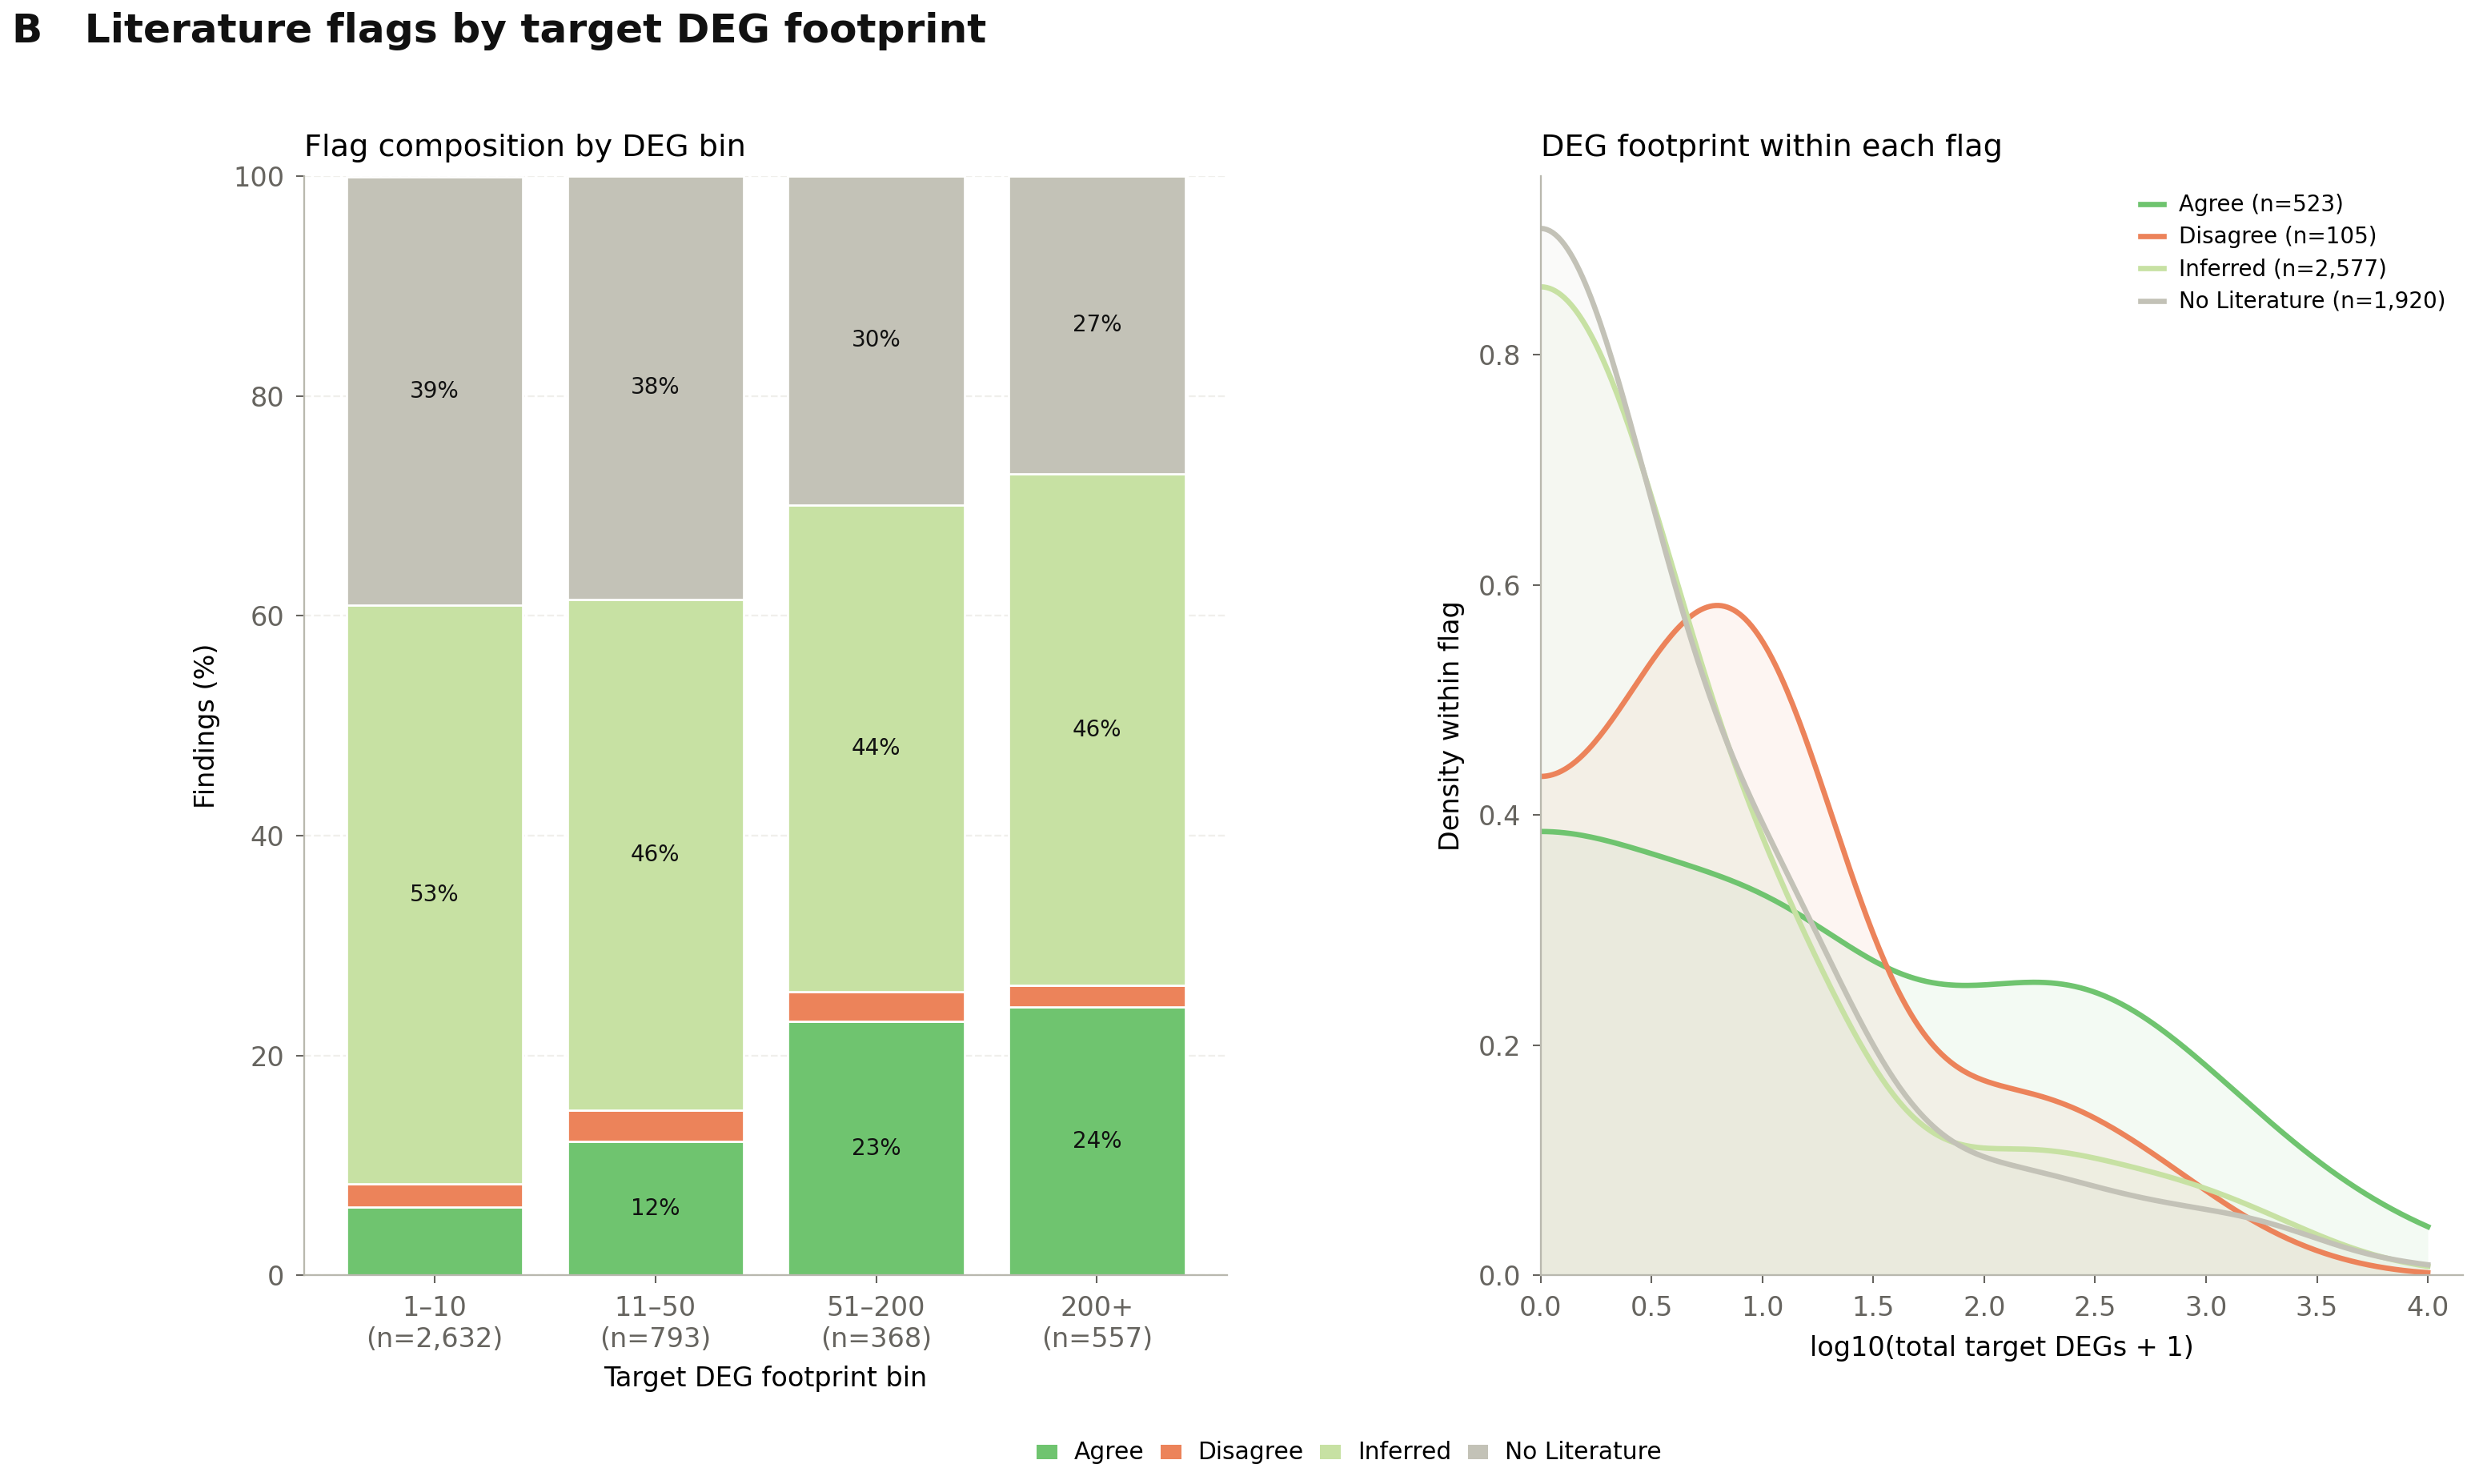

In [5]:
_CHROME = CHROME
_bins = S5B_BINS[S5B_BINS["deg_bin"].ne("0")].copy()
_rows = S5B_ROWS
_clean_axis = clean_axis
_flag_handles = flag_handles
_heading = heading

# ---------------------------------------------------------------- S5B
def draw_s5b(container):
    _heading(container, "B", "Literature flags by target DEG footprint")
    ax_bar, ax_kde = container.subplots(1, 2, gridspec_kw={"wspace": 0.34})

    x = np.arange(len(_bins))
    bottom = np.zeros(len(_bins), dtype=float)
    for key in FLAG_ORDER:
        values = _bins[f"{key}_percent"].to_numpy(dtype=float)
        ax_bar.bar(
            x,
            values,
            bottom=bottom,
            width=0.80,
            color=FLAG_COLORS[key],
            edgecolor="white",
            linewidth=0.65,
        )
        for xpos, low, value in zip(x, bottom, values):
            if value >= 9:
                ax_bar.text(
                    xpos,
                    low + value / 2,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color=_CHROME["ink"],
                )
        bottom += values
    ax_bar.set_xticks(
        x,
        [
            f"{row.deg_bin}\n(n={int(row.n_findings):,})"
            for row in _bins.itertuples()
        ],
    )
    ax_bar.set_ylim(0, 100)
    ax_bar.set_xlabel("Target DEG footprint bin")
    ax_bar.set_ylabel("Findings (%)")
    ax_bar.set_title("Flag composition by DEG bin", fontsize=8.0, loc="left")
    _clean_axis(ax_bar, "y")

    support_max = max(4.0, float(_rows["log10_deg_plus_1"].max()))
    grid = np.linspace(0, support_max, 300)
    for key in FLAG_ORDER:
        values = _rows.loc[
            _rows["flag_key"].eq(key), "log10_deg_plus_1"
        ].to_numpy(dtype=float)
        reflected = np.concatenate([values, -values])
        density = 2.0 * gaussian_kde(reflected, bw_method=0.25)(grid)
        ax_kde.fill_between(
            grid,
            0,
            density,
            color=FLAG_COLORS[key],
            alpha=0.08,
            linewidth=0,
        )
        ax_kde.plot(
            grid,
            density,
            color=FLAG_COLORS[key],
            linewidth=1.6,
            label=f"{FLAG_LABELS[key]} (n={len(values):,})",
        )
    ax_kde.set_xlim(0, support_max * 1.04)
    ax_kde.set_ylim(bottom=0)
    ax_kde.set_xlabel("log10(total target DEGs + 1)")
    ax_kde.set_ylabel("Density within flag")
    ax_kde.set_title("DEG footprint within each flag", fontsize=8.0, loc="left")
    ax_kde.legend(frameon=False, fontsize=5.8, handlelength=1.2)
    _clean_axis(ax_kde, None)

    container.legend(
        handles=_flag_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.035),
        ncol=4,
        frameon=False,
        fontsize=6.2,
        handlelength=1.0,
        columnspacing=0.8,
    )

fig_s5b, outputs_s5b = save_s5_panel("B", draw_s5b, (8.0, 4.1))
fig_s5b;

## Supplementary Figure 5C

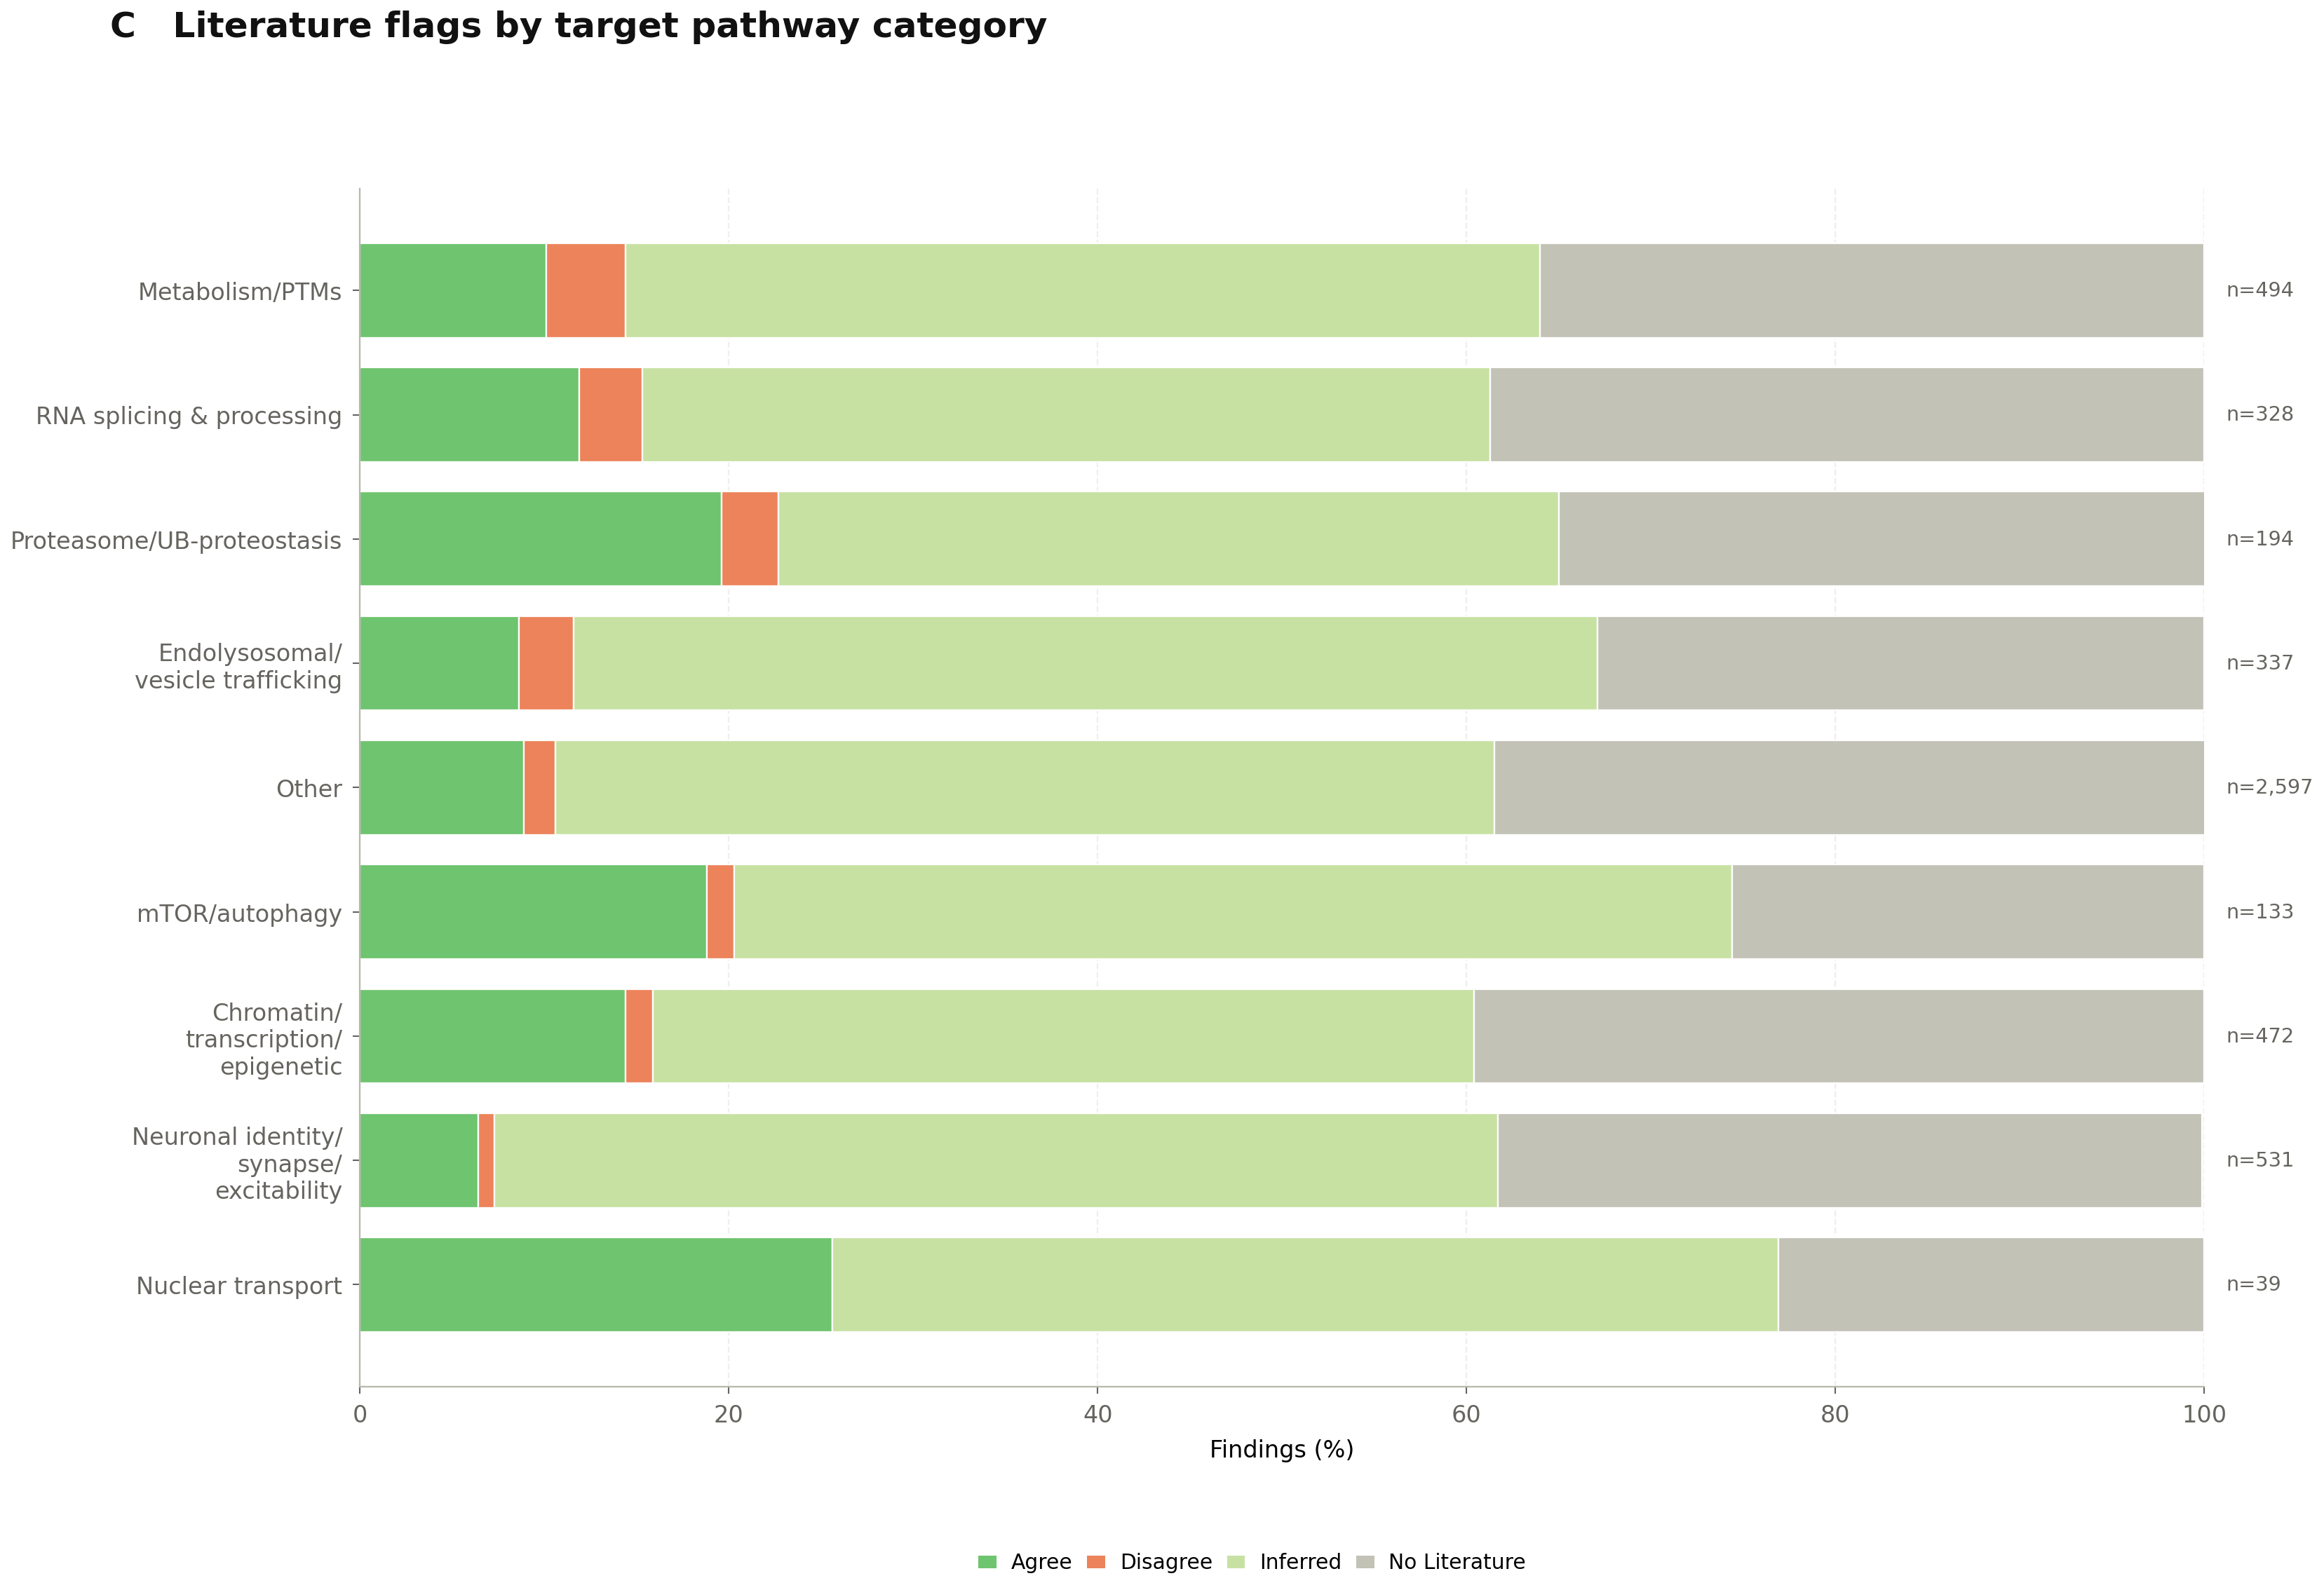

In [6]:
_CHROME = CHROME
_data = S5C_DATA[S5C_DATA["plotted"].astype(bool)].copy()
_data = _data.sort_values("disagree_percent", kind="stable")
_clean_axis = clean_axis
_flag_handles = flag_handles
_heading = heading

# ---------------------------------------------------------------- S5C
def draw_s5c(container):
    _heading(container, "C", "Literature flags by target pathway category")
    ax = container.subplots()
    y = np.arange(len(_data))
    left = np.zeros(len(_data), dtype=float)
    for key in FLAG_ORDER:
        values = _data[f"{key}_percent"].to_numpy(dtype=float)
        ax.barh(
            y,
            values,
            left=left,
            height=0.76,
            color=FLAG_COLORS[key],
            edgecolor="white",
            linewidth=0.55,
        )
        left += values
    labels = [
        value.replace("/", "/\n") if len(value) > 29 else value
        for value in _data["category"]
    ]
    ax.set_yticks(y, labels)
    for ypos, row in enumerate(_data.itertuples()):
        ax.text(
            101.2,
            ypos,
            f"n={int(row.n_findings):,}",
            ha="left",
            va="center",
            fontsize=6.0,
            color=_CHROME["muted"],
            clip_on=False,
        )
    ax.set_xlim(0, 100)
    ax.set_xlabel("Findings (%)")
    ax.tick_params(axis="y", length=0)
    _clean_axis(ax, "x")
    container.legend(
        handles=_flag_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
        fontsize=6.2,
        handlelength=1.0,
        columnspacing=0.8,
    )

fig_s5c, outputs_s5c = save_s5_panel("C", draw_s5c, (7.8, 5.1))
fig_s5c;

## Supplementary Figure 5D

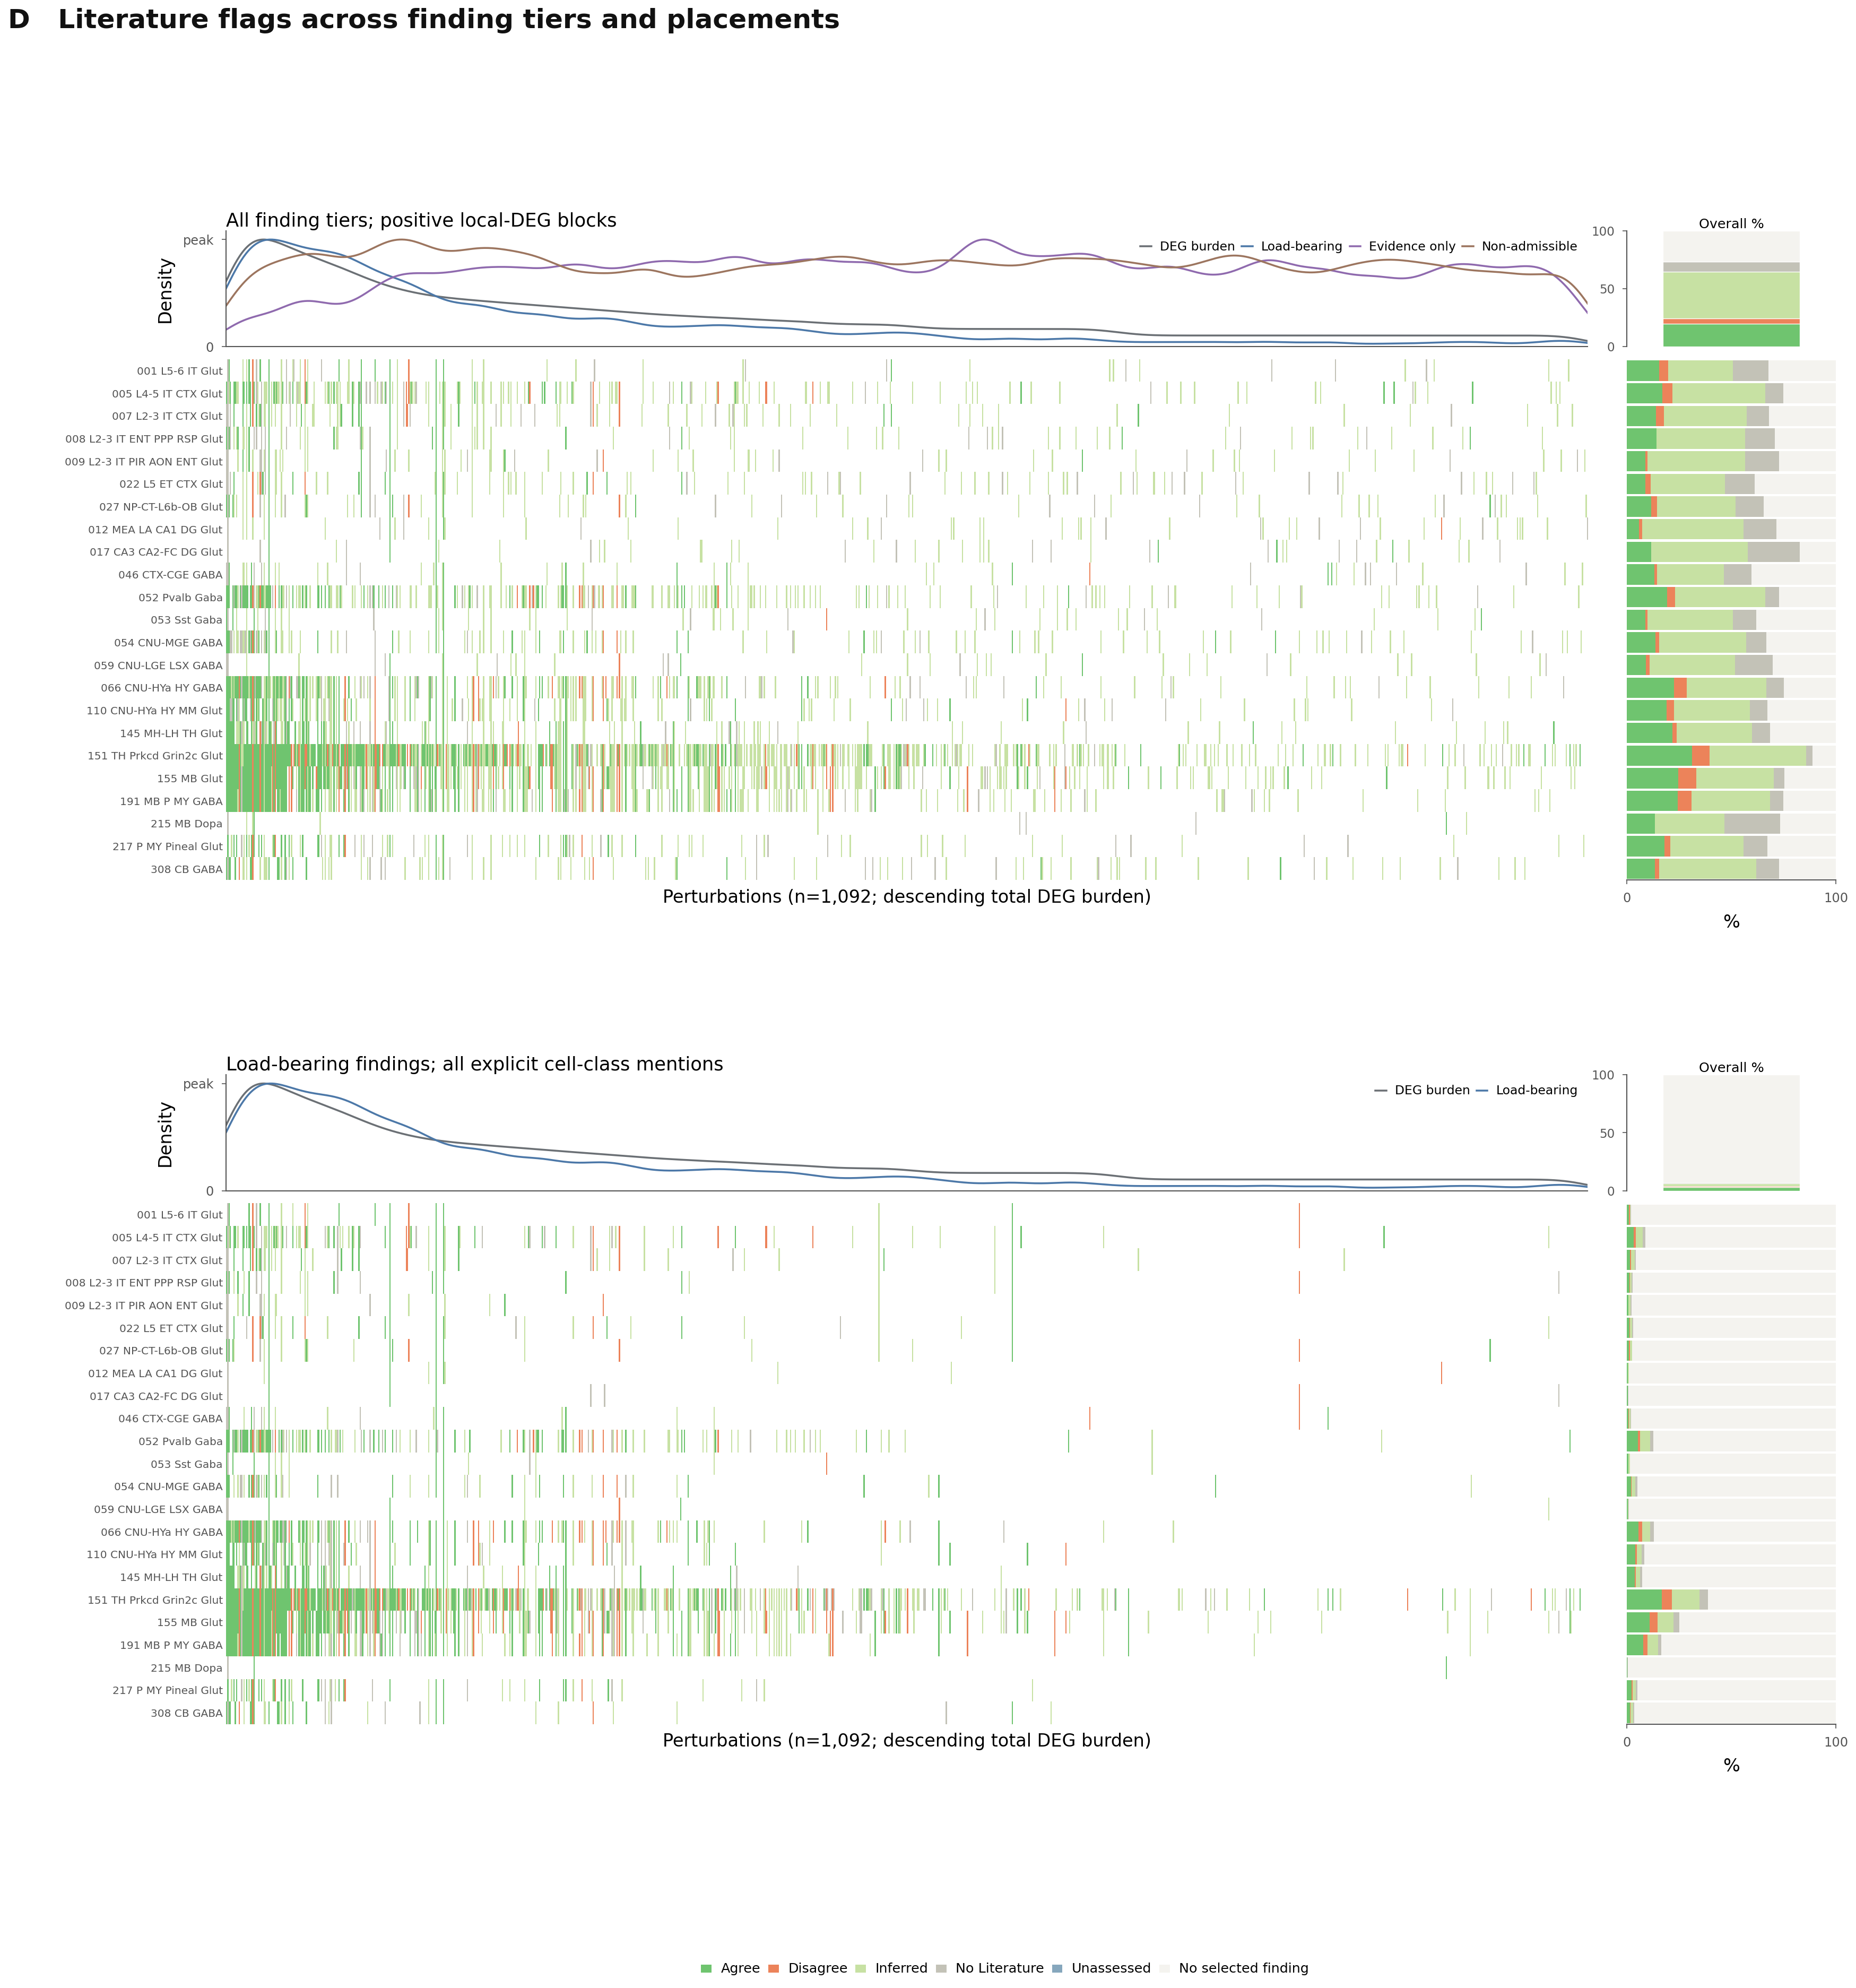

In [7]:
_CHROME = CHROME
_cells = S5D_CELLS
_findings = S5D_FINDINGS
_heading = heading
_normalize_flag = normalize_flag

_targets = list(pd.unique(_cells["perturbation"]))
_cell_types = list(pd.unique(_cells["cell_type"]))
_target_total = (
    _cells.groupby("perturbation", sort=False)["target_total_deg"]
    .first()
    .reindex(_targets)
)
_positive = (
    _cells.pivot(
        index="cell_type",
        columns="perturbation",
        values="in_positive_deg_universe",
    )
    .reindex(index=_cell_types, columns=_targets)
    .to_numpy(dtype=bool)
)
_pair_universe = _cells[
    ["perturbation", "cell_type", "in_positive_deg_universe"]
].copy()

_long = _findings.copy()
_long["cell_type"] = _long["cell_types"].fillna("").str.split(";")
_long = _long.explode("cell_type")
_long["cell_type"] = _long["cell_type"].str.strip()
_long = _long[_long["cell_type"].isin(_cell_types)].copy()
_long["flag_key"] = _long["flag"].map(_normalize_flag)
_long.loc[_long["flag_key"].eq(""), "flag_key"] = UNFLAGGED_KEY

_priority = {
    UNFLAGGED_KEY: -1,
    "no_literature": 0,
    "inferred": 1,
    "agree": 2,
    "disagree": 3,
}
_matrix_order = (*FLAG_ORDER, UNFLAGGED_KEY)
_code = {key: index + 1 for index, key in enumerate(_matrix_order)}

def _resolve_matrix(levels, require_positive_deg):
    selected = _long[_long["phenotype_confidence"].isin(levels)].copy()
    selected = selected.merge(
        _pair_universe,
        on=["perturbation", "cell_type"],
        how="inner",
        validate="many_to_one",
    )
    if require_positive_deg:
        selected = selected[selected["in_positive_deg_universe"].eq(1)]
    chosen = (
        selected.groupby(["cell_type", "perturbation"], sort=False)["flag_key"]
        .agg(lambda values: max(values, key=_priority.get))
        .unstack()
        .reindex(index=_cell_types, columns=_targets)
    )
    return chosen.map(lambda value: _code.get(value, 0)).to_numpy(dtype=int)

_all_tiers_positive = _resolve_matrix(("high", "moderate", "low"), True)
_load_bearing_mentions = _resolve_matrix(("high",), False)
_finding_counts = (
    _findings.groupby(["perturbation", "phenotype_confidence"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(_targets, fill_value=0)
)

def _peak_density(values, bandwidth=18):
    radius = 4 * bandwidth
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / bandwidth) ** 2)
    kernel /= kernel.sum()
    smoothed = np.convolve(np.asarray(values, dtype=float), kernel, mode="same")
    return smoothed / smoothed.max() if smoothed.max() else smoothed

def _draw_heatmap_variant(container, slot, matrix, eligible, levels, title):
    grid = slot.subgridspec(
        2,
        2,
        height_ratios=(1.0, 4.5),
        width_ratios=(8.8, 1.35),
        hspace=0.04,
        wspace=0.05,
    )
    ax_density = container.add_subplot(grid[0, 0])
    ax_overall = container.add_subplot(grid[0, 1])
    ax_matrix = container.add_subplot(grid[1, 0])
    ax_mix = container.add_subplot(grid[1, 1], sharey=ax_matrix)

    matrix_colors = [
        "#ffffff",
        *[FLAG_COLORS[key] for key in FLAG_ORDER],
        UNFLAGGED_COLOR,
    ]
    cmap = mcolors.ListedColormap(matrix_colors)
    norm = mcolors.BoundaryNorm(
        np.arange(-0.5, len(matrix_colors) + 0.5), cmap.N
    )
    ax_matrix.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    ax_matrix.set_yticks(np.arange(len(_cell_types)), _cell_types, fontsize=4.2)
    ax_matrix.set_xticks([])
    ax_matrix.set_xlabel(
        f"Perturbations (n={len(_targets):,}; descending total DEG burden)"
    )
    ax_matrix.tick_params(axis="y", length=0, pad=1.5)
    for spine in ax_matrix.spines.values():
        spine.set_visible(False)

    density_series = [
        (
            _peak_density(np.log10(1 + _target_total.to_numpy(dtype=float))),
            "DEG burden",
            _CHROME["deg"],
        )
    ]
    tier_style = {
        "high": ("Load-bearing", _CHROME["high"]),
        "moderate": ("Evidence only", _CHROME["moderate"]),
        "low": ("Non-admissible", "#9C755F"),
    }
    for level in levels:
        label, color = tier_style[level]
        values = _finding_counts.get(level, pd.Series(0, index=_targets))
        density_series.append((_peak_density(values.to_numpy()), label, color))
    x = np.arange(len(_targets))
    for values, label, color in density_series:
        ax_density.plot(x, values, color=color, linewidth=0.85, label=label)
    ax_density.set_xlim(0, len(_targets) - 1)
    ax_density.set_ylim(0, 1.08)
    ax_density.set_xticks([])
    ax_density.set_yticks([0, 1], ["0", "peak"])
    ax_density.set_ylabel("Density")
    ax_density.set_title(title, loc="left", fontsize=7.4, pad=2)
    ax_density.legend(
        frameon=False,
        fontsize=4.9,
        ncol=len(density_series),
        loc="upper right",
        handlelength=1.0,
        columnspacing=0.6,
    )
    ax_density.spines[["top", "right"]].set_visible(False)
    ax_density.tick_params(length=2, width=0.4, labelsize=5.0)

    mix_order = (*_matrix_order, "uncovered")
    mix_colors = {
        **FLAG_COLORS,
        UNFLAGGED_KEY: UNFLAGGED_COLOR,
        "uncovered": _CHROME["uncovered"],
    }
    mix_code = {key: _code.get(key, 0) for key in mix_order}
    y = np.arange(len(_cell_types))
    left = np.zeros(len(_cell_types), dtype=float)
    for key in mix_order:
        fractions = []
        for row_index in range(len(_cell_types)):
            row_values = matrix[row_index, eligible[row_index]]
            code_value = mix_code[key]
            fractions.append(100 * float(np.sum(row_values == code_value)) / len(row_values))
        ax_mix.barh(
            y,
            fractions,
            left=left,
            height=0.90,
            color=mix_colors[key],
            edgecolor="none",
        )
        left += np.asarray(fractions)
    ax_mix.set_xlim(0, 100)
    ax_mix.set_xticks([0, 100])
    ax_mix.set_xlabel("%")
    ax_mix.tick_params(axis="y", left=False, labelleft=False)
    ax_mix.spines[["top", "right", "left"]].set_visible(False)
    ax_mix.tick_params(axis="x", length=2, width=0.4, labelsize=5.0)

    overall_values = matrix[eligible]
    bottom = 0.0
    for key in mix_order:
        height = 100 * float(np.sum(overall_values == mix_code[key])) / len(overall_values)
        ax_overall.bar(
            0,
            height,
            bottom=bottom,
            width=0.72,
            color=mix_colors[key],
            edgecolor="white",
            linewidth=0.3,
        )
        bottom += height
    ax_overall.set_xlim(-0.55, 0.55)
    ax_overall.set_ylim(0, 100)
    ax_overall.set_xticks([])
    ax_overall.set_yticks([0, 50, 100])
    ax_overall.set_title("Overall %", fontsize=5.3, pad=1)
    ax_overall.spines[["top", "right", "bottom"]].set_visible(False)
    ax_overall.tick_params(axis="y", length=2, width=0.4, labelsize=4.8)

# ---------------------------------------------------------------- S5D
def draw_s5d(container):
    _heading(container, "D", "Literature flags across finding tiers and placements")
    outer = container.add_gridspec(2, 1, hspace=0.30)
    _draw_heatmap_variant(
        container,
        outer[0],
        _all_tiers_positive,
        _positive,
        ("high", "moderate", "low"),
        "All finding tiers; positive local-DEG blocks",
    )
    _draw_heatmap_variant(
        container,
        outer[1],
        _load_bearing_mentions,
        np.ones_like(_positive, dtype=bool),
        ("high",),
        "Load-bearing findings; all explicit cell-class mentions",
    )
    handles = [
        *[
            Patch(
                facecolor=FLAG_COLORS[key],
                edgecolor="none",
                label=FLAG_LABELS[key],
            )
            for key in FLAG_ORDER
        ],
        Patch(facecolor=UNFLAGGED_COLOR, edgecolor="none", label="Unassessed"),
        Patch(
            facecolor=_CHROME["uncovered"],
            edgecolor="none",
            label="No selected finding",
        ),
    ]
    container.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=6,
        frameon=False,
        fontsize=5.3,
        handlelength=0.9,
        columnspacing=0.65,
    )

fig_s5d, outputs_s5d = save_s5_panel("D", draw_s5d, (9.0, 8.4))
fig_s5d;

## Supplementary Figure 5E

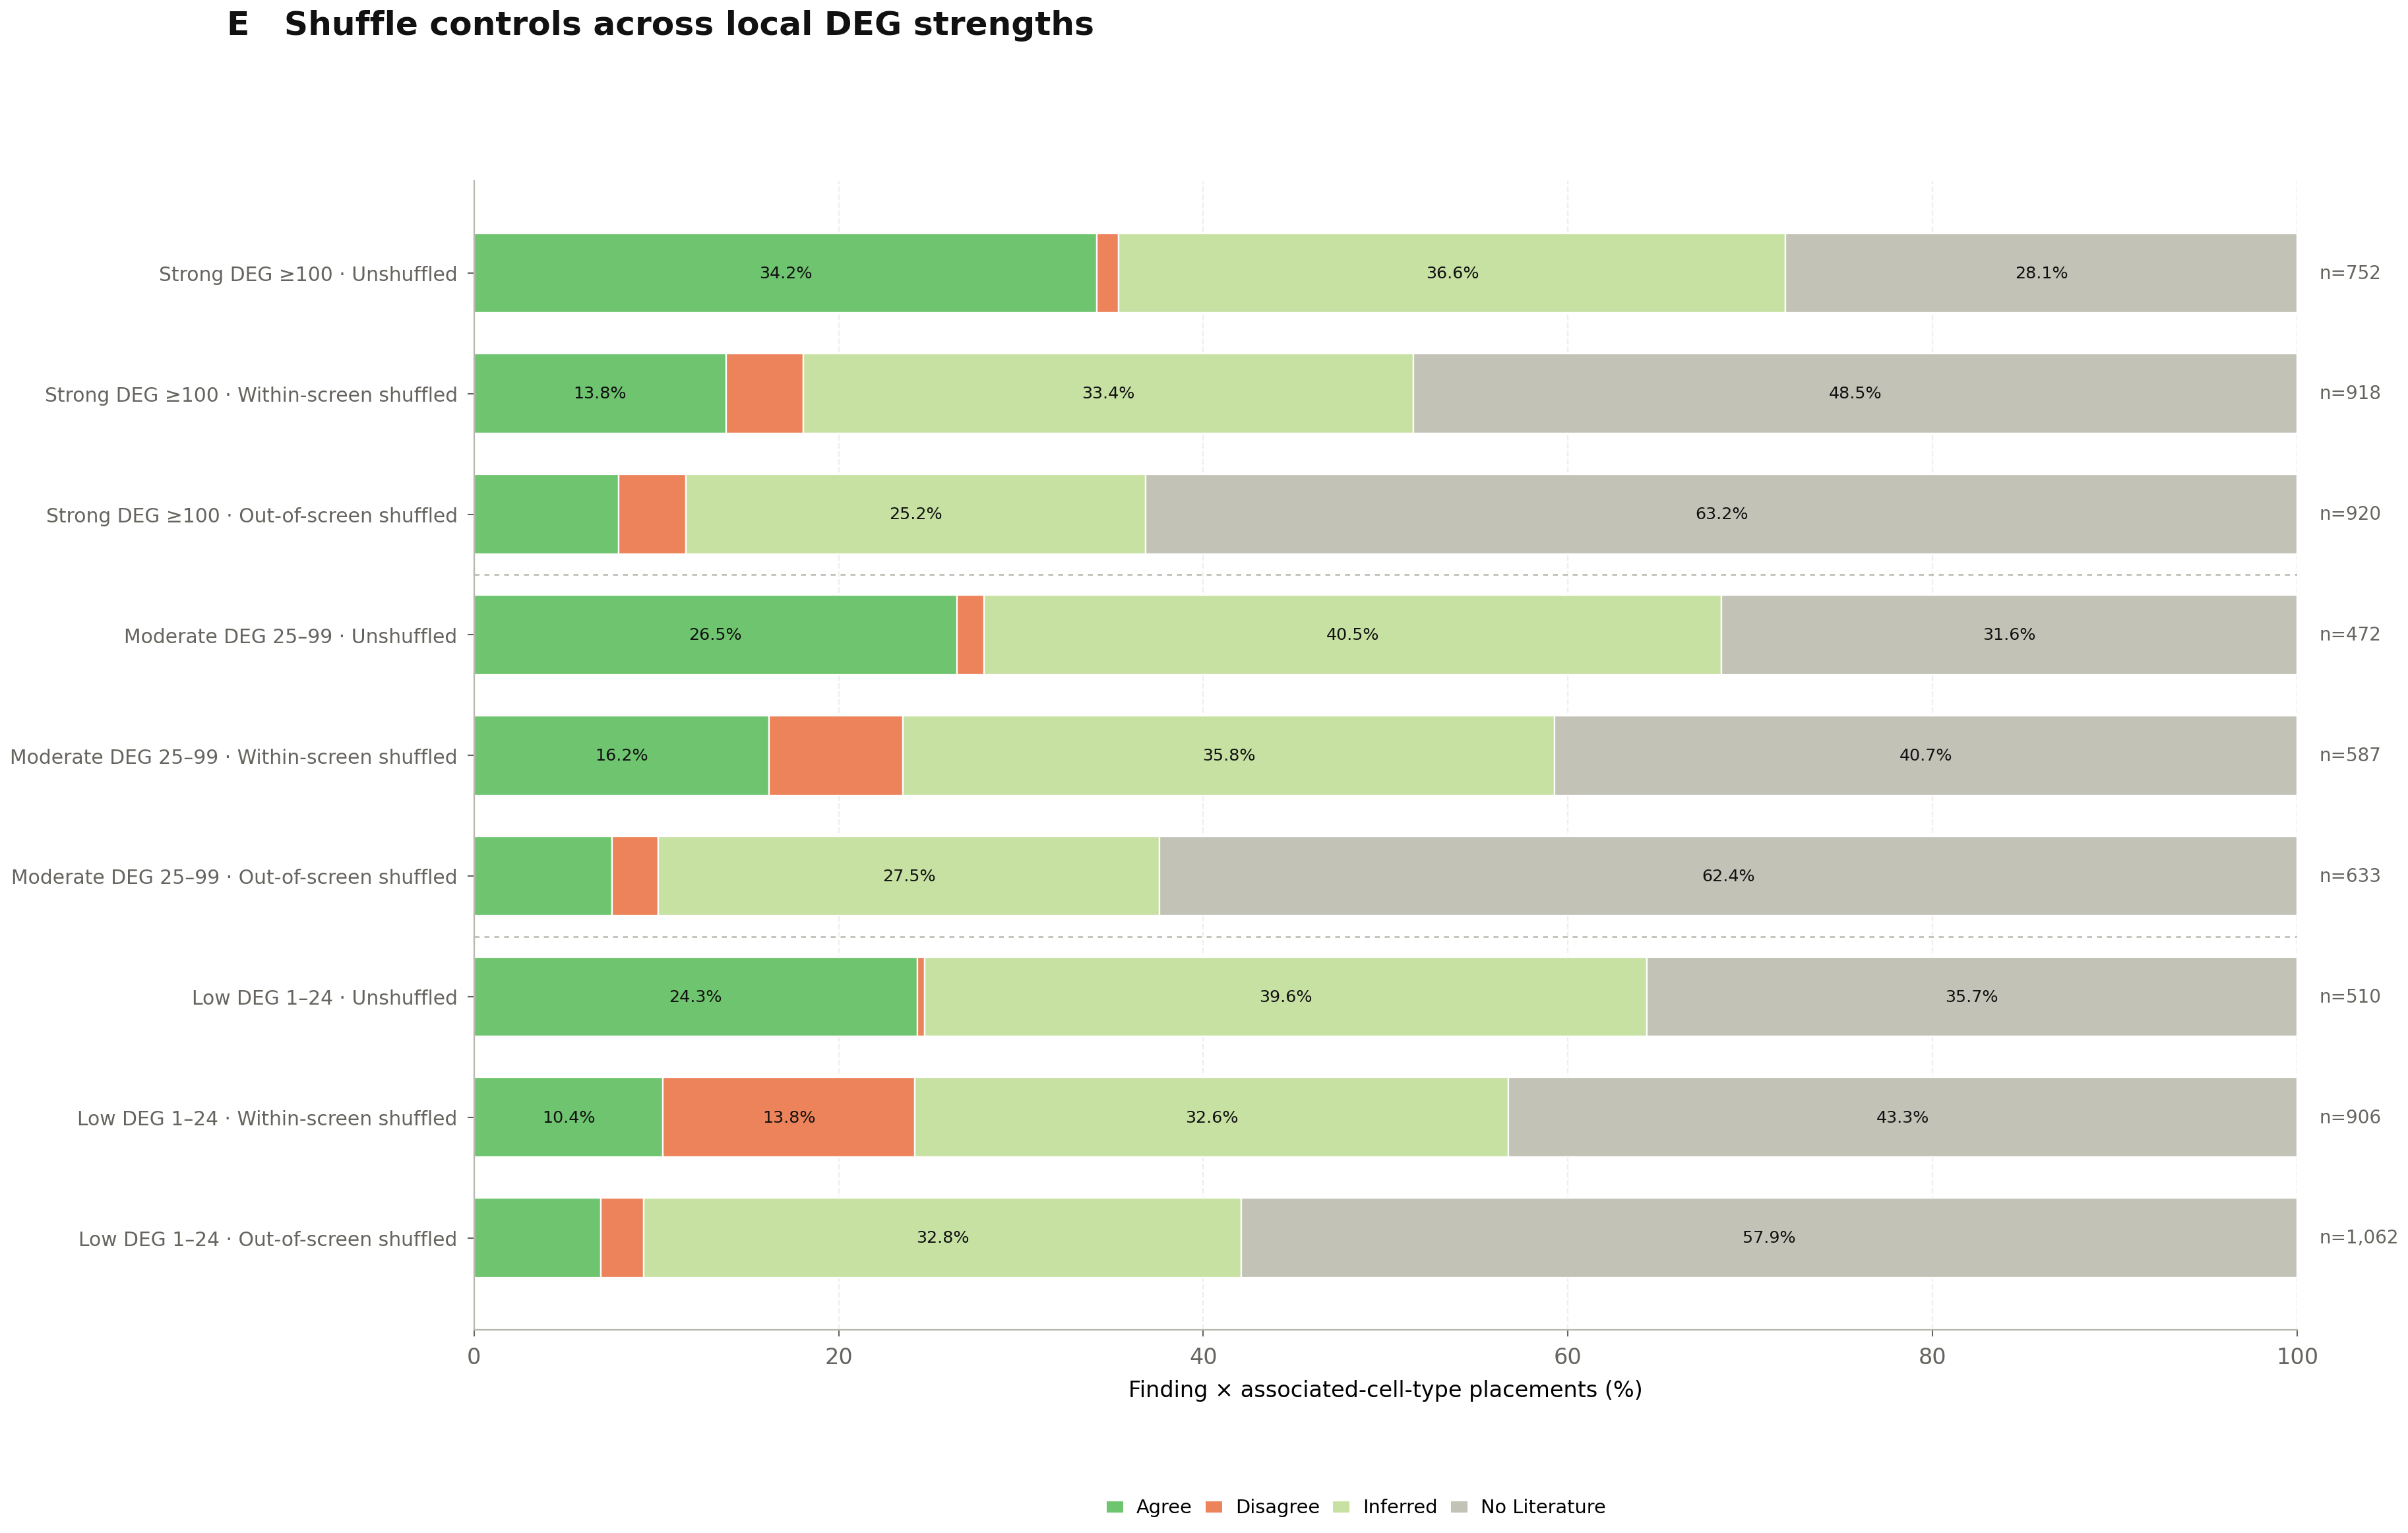

In [8]:
_CHROME = CHROME
_clean_axis = clean_axis
_flag_handles = flag_handles
_heading = heading
_data = S5E_DATA[
    S5E_DATA["analysis_layer"].eq("primary")
    & S5E_DATA["local_signal_stratum"].isin(["Strong", "Moderate", "Low"])
].copy()
_strata = ("Strong", "Moderate", "Low")
_arms = ("Unshuffled", "Within-screen shuffled", "Out-of-screen shuffled")
_stratum_label = {
    "Strong": "Strong DEG ≥100",
    "Moderate": "Moderate DEG 25–99",
    "Low": "Low DEG 1–24",
}
_arm_label = {
    "Unshuffled": "Unshuffled",
    "Within-screen shuffled": "Within-screen shuffled",
    "Out-of-screen shuffled": "Out-of-screen shuffled",
}

# ---------------------------------------------------------------- S5E
def draw_s5e(container):
    _heading(container, "E", "Shuffle controls across local DEG strengths")
    ax = container.subplots()
    labels = [(stratum, arm) for stratum in _strata for arm in _arms]
    y = np.arange(len(labels))
    left = np.zeros(len(labels), dtype=float)
    lookup = _data.set_index(["local_signal_stratum", "arm", "flag"])
    for key in FLAG_ORDER:
        values = np.array(
            [float(lookup.loc[(stratum, arm, key), "percent"]) for stratum, arm in labels]
        )
        ax.barh(
            y,
            values,
            left=left,
            height=0.66,
            color=FLAG_COLORS[key],
            edgecolor="white",
            linewidth=0.55,
        )
        for ypos, low, value in zip(y, left, values):
            if value >= 9:
                ax.text(
                    low + value / 2,
                    ypos,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=5.3,
                    color=_CHROME["ink"],
                )
        left += values
    tick_labels = [
        f"{_stratum_label[stratum]} · {_arm_label[arm]}"
        for stratum, arm in labels
    ]
    ax.set_yticks(y, tick_labels)
    ax.invert_yaxis()
    for ypos, (stratum, arm) in enumerate(labels):
        n = int(lookup.loc[(stratum, arm, FLAG_ORDER[0]), "n_placements"])
        ax.text(
            101.2,
            ypos,
            f"n={n:,}",
            ha="left",
            va="center",
            fontsize=5.8,
            color=_CHROME["muted"],
            clip_on=False,
        )
    for boundary in (2.5, 5.5):
        ax.axhline(boundary, color=_CHROME["axis"], linewidth=0.6, linestyle=(0, (3, 3)))
    ax.set_xlim(0, 100)
    ax.set_xlabel("Finding × associated-cell-type placements (%)")
    ax.tick_params(axis="y", length=0, labelsize=6.2)
    _clean_axis(ax, "x")
    container.legend(
        handles=_flag_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=4,
        frameon=False,
        fontsize=6.0,
        handlelength=1.0,
        columnspacing=0.8,
    )

fig_s5e, outputs_s5e = save_s5_panel("E", draw_s5e, (8.2, 5.2))
fig_s5e;